# 3. Инференс финальной модели и итоговые метрики

1. Запуск сохранённой модели так, как её запускают организаторы: `load` + `run` на папке испытуемых, CSV `subject_id, ptsd_probability` (3.1).
2. Устойчивость к плохим входам и совпадение признаков при обучении и инференсе (3.2–3.3).
3. Итоговые метрики по OOF-вероятностям вложенной валидации: ROC-AUC с бутстрэп-ДИ (2000 итераций по группам), сбалансированная точность, специфичность на нормах 65+ и соматоформных при пороге 0.5, метрики по возрастным подгруппам, калибровка (3.4–3.8).
4. Оценка баллов по формуле ТЗ (3.9).

**Какие вероятности чему соответствуют.** Предсказания финальной модели на её же обучающих испытуемых оптимистичны и метрикой не являются — они показаны только для сравнения (3.3). Честная оценка качества — OOF-вероятности вложенной валидации: каждого испытуемого предсказывает модель, которая не видела ни его, ни его копий и прошла полный цикл выбора и калибровки без него (ноутбук 2, раздел 2.7; сохранены в `results/validation/protocol7/nested_oof.csv`).

In [1]:
import shutil
import sys
import tempfile
import time
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

from model.model import load, predict, run
from src import config, dataset, evaluation, models, viz

warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 3)
WEIGHTS = ROOT / "model" / "weights"
OOF_PATH = ROOT / "results" / "validation" / "protocol7" / "nested_oof.csv"

## 3.1 Запуск как у организаторов

`model/model.py` предоставляет неизменяемый интерфейс ТЗ: `load(path)` читает веса из `model/weights/model.json`, `predict(model, subject_dir)` возвращает вероятность для папки одного испытуемого, `run(model, input_dir, output_path)` обходит все папки и пишет CSV. Модель работает с сырыми EDF: вся предобработка и признаки вызываются внутри `predict`. Обучение при этом не выполняется.

Для демонстрации во временную папку копируется по одному испытуемому каждой страты — так выглядит тестовая папка: подпапка на испытуемого с файлами `T-П.edf`, `T-1.edf` … `T-5.edf` (у части партий только покой или покой и первая проба).

In [2]:
model = load(WEIGHTS)
print(f"Модель: {model.metadata['protocol']}, {model.metadata['candidate']}, признаков {len(model.feature_names)}; "
      f"калибровка Платта a = {model.calibration[0]:.3f}, b = {model.calibration[1]:.3f}")

data = models.load_training_data(protocol=models.PROTOCOL_7)
stratum_of = dict(zip(data.subject_keys, data.stratum))
demo = [next(k for k in data.subject_keys if stratum_of[k] == s) for s in viz.STRATUM_ORDER]

tmp = Path(tempfile.mkdtemp())
input_dir = tmp / "input"
for key in demo:
    shutil.copytree(config.DATA_DIR / key, input_dir / Path(key).name)
start = time.perf_counter()
run(model, input_dir, tmp / "predictions.csv")
elapsed = time.perf_counter() - start
predictions = pd.read_csv(tmp / "predictions.csv", encoding="utf-8-sig")
print(f"{len(predictions)} испытуемых за {elapsed:.1f} с ({elapsed / len(predictions):.2f} с на испытуемого)")
predictions.assign(страта=[viz.STRATUM_LABELS[stratum_of[k]] for k in sorted(demo, key=lambda k: Path(k).name)])

Модель: protocol7, C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp, признаков 23; калибровка Платта a = 0.822, b = 0.338


7 испытуемых за 0.8 с (0.11 с на испытуемого)


,subject_id,ptsd_probability,страта
0,34PHG,0.733,ПТСР
1,A003_68,0.015,нормы 65+
2,ABXZ5,0.493,соматоформные
3,КС010_19,0.850,норма A
4,КС027_34,0.802,норма B
5,КС056_22,0.147,норма C
6,КС201_23,0.609,доп. нормы


Эти семь испытуемых входили в обучение финальной модели, поэтому их вероятности не являются оценкой качества — здесь проверяется только механика запуска.

## 3.2 Устойчивость к плохим входам

`predict` не падает на плохих данных: пропущенные, пустые и нечитаемые файлы пропускаются, а у испытуемого без годных данных признаки заменяются медианами обучающей выборки. Проверка: пустая папка, папка только с покоем, папка с обрезанным (повреждённым) EDF, папка с файлами с кириллическими буквами в именах.

In [3]:
bad_dir = tmp / "bad_input"
source = config.DATA_DIR / demo[0]  # a PTSD subject with rest and five trials
(bad_dir / "empty").mkdir(parents=True)
(bad_dir / "rest_only").mkdir()
shutil.copy(source / "T-П.edf", bad_dir / "rest_only" / "T-П.edf")
(bad_dir / "truncated").mkdir()
(bad_dir / "truncated" / "T-П.edf").write_bytes((source / "T-П.edf").read_bytes()[:3000])
(bad_dir / "cyrillic_names").mkdir()
shutil.copy(source / "T-П.edf", bad_dir / "cyrillic_names" / "Т-П.edf")  # Cyrillic "Т"
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    run(model, bad_dir, tmp / "bad_predictions.csv")
bad = pd.read_csv(tmp / "bad_predictions.csv", encoding="utf-8-sig")
print("Все вероятности конечны и в [0, 1]:", bool(bad["ptsd_probability"].between(0, 1).all()))
print("Предупреждений:", len(caught))
bad

Все вероятности конечны и в [0, 1]: True
Предупреждений: 0


,subject_id,ptsd_probability
0,cyrillic_names,0.733
1,empty,0.217
2,rest_only,0.733
3,truncated,0.217


Папки «только покой» и «кириллические имена» дают ту же вероятность, что и полный набор файлов этого испытуемого: модель использует только покой, а имена файлов сопоставляются без учёта кириллических двойников латинских букв. Пустая папка и повреждённый файл получают вероятность «все признаки неизвестны» (медианы обучения).

## 3.3 Одинаковые признаки при обучении и инференсе

Обучение строит таблицу признаков через `models.load_training_data`, инференс — через `predict` по папке испытуемого. Если бы пути расходились (другой порядок каналов, другая политика файлов), модель на тесте получала бы другие признаки, чем при обучении. Сравниваются вероятности финальной модели по двум путям для всех 229 испытуемых.

In [4]:
start = time.perf_counter()
p_inference = np.array([predict(model, config.DATA_DIR / key) for key in data.subject_keys])
elapsed = time.perf_counter() - start
p_training = model.predict_proba(data.tables[model.metadata["feature_set"]])
print(f"Инференс 229 испытуемых: {elapsed:.0f} с; максимальное расхождение с обучающей таблицей: "
      f"{np.abs(p_inference - p_training).max():.1e}")

Инференс 229 испытуемых: 13 с; максимальное расхождение с обучающей таблицей: 3.3e-16


In [5]:
oof = pd.read_csv(OOF_PATH, index_col=0).loc[list(data.subject_keys)]
stratum, groups = oof["stratum"].to_numpy(), oof["split_group"].to_numpy()
ptsd = stratum == models.STRATUM_PTSD
young = np.isin(stratum, ["control_A", "control_B", "control_C", "control_B_supplement"])


def auc_vs(p: np.ndarray, negatives: np.ndarray) -> float:
    mask = ptsd | negatives
    return roc_auc_score(ptsd[mask], p[mask])


pd.DataFrame({
    "финальная модель на обучающих данных (оптимистично)": {
        "AUC ПТСР / нормы < 65": auc_vs(p_inference, young),
        "AUC ПТСР / нормы 65+ и соматоформные": auc_vs(p_inference, np.isin(stratum, ["control_ageing", "somatoform"])),
        "чувствительность при 0.5": np.mean(p_inference[ptsd] >= 0.5)},
    "вложенная валидация, OOF (оценка качества)": {
        "AUC ПТСР / нормы < 65": auc_vs(oof["p_raw"].to_numpy(), young),
        "AUC ПТСР / нормы 65+ и соматоформные": auc_vs(oof["p_raw"].to_numpy(), np.isin(stratum, ["control_ageing", "somatoform"])),
        "чувствительность при 0.5": np.mean(oof["p"].to_numpy()[ptsd] >= 0.5)},
})

,финальная модель на обучающих данных (оптимистично),"вложенная валидация, OOF (оценка качества)"
AUC ПТСР / нормы < 65,0.923,0.838
AUC ПТСР / нормы 65+ и соматоформные,0.894,0.781
чувствительность при 0.5,0.960,0.800


Разница между столбцами — оптимизм оценки на обучающих данных. Дальше все метрики — только по OOF.

## 3.4 Итоговые метрики вложенной валидации

ROC-AUC с 95% ДИ: бутстрэп 2000 итераций, ресэмплируются независимые группы (а не записи) отдельно внутри ПТСР и внутри отрицательного класса. «Нормы < 65» — все нормы моложе 65 лет (пара «ПТСР/контроль» ТЗ; состав тестовой пары организаторов неизвестен, поэтому показан и вариант без формата C). Пороговые метрики — по сдаваемой калиброванной вероятности при P = 0.5.

In [6]:
report = evaluation.summarize_protocol3(oof, groups)
p, p_raw = oof["p"].to_numpy(), oof["p_raw"].to_numpy()


def ci(entry: dict) -> str:
    return f"{entry['value']:.3f} [{entry['ci_low']:.3f}; {entry['ci_high']:.3f}]"


auc_rows = {"ПТСР / нормы < 65": "auc_ptsd_vs_controls_excl_ageing", "ПТСР / нормы A, B, доп. партия": "auc_ptsd_vs_controls_AB"}
auc_table = pd.DataFrame({
    col: {**{name: ci(report[col][key]) for name, key in auc_rows.items()},
          **{f"ПТСР / {viz.STRATUM_LABELS[s]}": f"{v:.3f}" for s, v in report[col]["auc_ptsd_vs_stratum"].items()}}
    for col in ("p_raw", "p")
}).rename(columns={"p_raw": "некалиброванная", "p": "калиброванная (сдаётся)"})
auc_table.rename_axis("ROC-AUC")

,некалиброванная,калиброванная (сдаётся)
ROC-AUC,,
ПТСР / нормы < 65,0.838 [0.765; 0.901],0.803 [0.725; 0.869]
"ПТСР / нормы A, B, доп. партия",0.720 [0.610; 0.825],0.661 [0.547; 0.776]
ПТСР / норма A,0.620,0.570
ПТСР / норма B,0.380,0.400
ПТСР / доп. нормы,0.787,0.719
ПТСР / норма C,1.000,1.000
ПТСР / нормы 65+,0.873,0.875
ПТСР / соматоформные,0.752,0.714


In [7]:
sens = evaluation.rate_with_ci(p[ptsd] >= 0.5, groups[ptsd])
spec_young = evaluation.rate_with_ci(p[young] < 0.5, groups[young])
threshold = {
    "чувствительность (ПТСР)": ci(sens),
    "специфичность: нормы < 65": ci(spec_young),
    "специфичность: нормы 65+": ci(report["p"]["specificity_ageing"]),
    "специфичность: соматоформные": ci(report["p"]["specificity_somatoform"]),
    "специфичность: 65+ и соматоформные вместе": ci(report["p"]["specificity_ageing_and_somatoform_pooled"]),
    "сбалансированная точность: ПТСР / нормы < 65": f"{0.5 * (sens['value'] + spec_young['value']):.3f}",
    "сбалансированная точность: ПТСР / все не-ПТСР": f"{report['p']['threshold_metrics']['balanced_accuracy_vs_all_non_ptsd']:.3f}",
    "Brier (все испытуемые)": f"{report['p']['brier_all_subjects']:.3f}",
}
pd.Series(threshold, name="порог 0.5, калиброванная вероятность").to_frame()

,"порог 0.5, калиброванная вероятность"
чувствительность (ПТСР),0.800 [0.625; 0.958]
специфичность: нормы < 65,0.692 [0.607; 0.776]
специфичность: нормы 65+,0.783 [0.609; 0.913]
специфичность: соматоформные,0.581 [0.472; 0.693]
специфичность: 65+ и соматоформные вместе,0.629 [0.526; 0.726]
сбалансированная точность: ПТСР / нормы < 65,0.746
сбалансированная точность: ПТСР / все не-ПТСР,0.731
Brier (все испытуемые),0.196


## 3.5 ROC-кривые

Слева — пара «ПТСР/контроль» в двух вариантах состава, справа — группы, на которых ТЗ проверяет специфичность. Кривые — по некалиброванной OOF-вероятности, которая сохраняет ранжирование финальной модели (ноутбук 2, раздел 2.7).

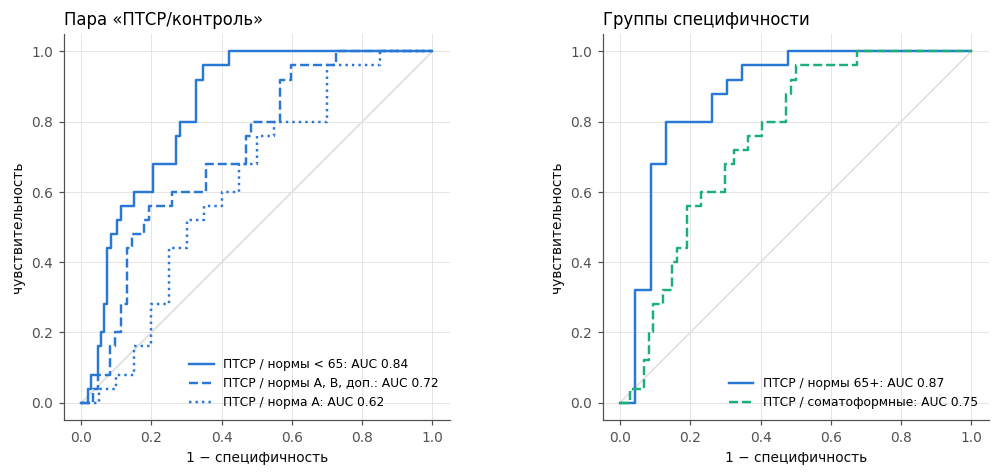

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
control = viz.COHORT_COLORS[config.GROUP_CONTROL]
panels = [
    [("нормы < 65", young, "-"), ("нормы A, B, доп.", np.isin(stratum, ["control_A", "control_B", "control_B_supplement"]), "--"),
     ("норма A", stratum == "control_A", ":")],
    [("нормы 65+", stratum == "control_ageing", "-"), ("соматоформные", stratum == "somatoform", "--")],
]
for ax, panel in zip(axes, panels):
    for label, negatives, ls in panel:
        mask = ptsd | negatives
        color = viz.COHORT_COLORS[config.GROUP_SOMATOFORM] if label == "соматоформные" else control
        viz.plot_roc(ax, ptsd[mask].astype(int), p_raw[mask], f"ПТСР / {label}", color, ls)
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_title("Пара «ПТСР/контроль»", loc="left")
axes[1].set_title("Группы специфичности", loc="left")
plt.tight_layout()
plt.show()

## 3.6 Вероятность по стратам и порог 0.5

Точка — испытуемый (OOF, калиброванная вероятность), линия — медиана, пунктир — порог 0.5. Ниже — доля испытуемых с P ≥ 0.5 в каждой страте (для ПТСР это чувствительность, для остальных — доля ложноположительных) с 95% ДИ по бутстрэпу групп.

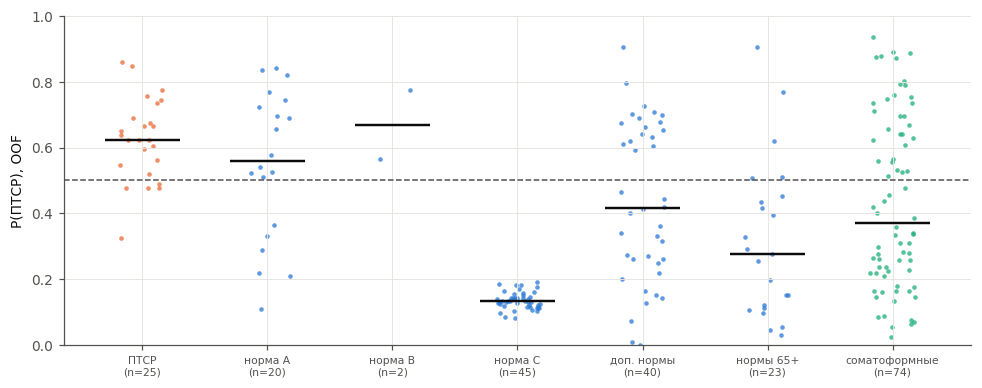

,n,доля P ≥ 0.5,2.5%,97.5%,медиана P
ПТСР,25.0,0.800,0.625,0.958,0.624
норма A,20.0,0.700,0.500,0.900,0.559
норма B,2.0,1.000,1.000,1.000,0.670
норма C,45.0,0.000,0.000,0.000,0.132
доп. нормы,40.0,0.425,0.275,0.575,0.416
нормы 65+,23.0,0.217,0.087,0.391,0.276
соматоформные,74.0,0.419,0.307,0.528,0.372


In [9]:
fig, ax = plt.subplots(figsize=(9, 3.6))
viz.plot_by_stratum(ax, p, stratum)
ax.axhline(0.5, color=viz.TEXT_MUTED, ls="--", lw=1)
ax.set_ylabel("P(ПТСР), OOF")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

rows = {}
for s in viz.STRATUM_ORDER:
    m = stratum == s
    r = evaluation.rate_with_ci(p[m] >= 0.5, groups[m])
    rows[viz.STRATUM_LABELS[s]] = {"n": int(m.sum()), "доля P ≥ 0.5": r["value"], "2.5%": r["ci_low"], "97.5%": r["ci_high"],
                                   "медиана P": float(np.median(p[m]))}
pd.DataFrame(rows).T

## 3.7 Метрики по возрастным подгруппам

Возраст известен только у норм (из имени папки). ПТСР по ТЗ — 18–45 лет, возраст отдельного испытуемого неизвестен, поэтому в каждой подгруппе AUC считается как «все ПТСР против норм этого возраста». Состав подгрупп по партиям разный (ниже), поэтому возраст здесь переплетён с форматом и партией; отдельная проверка возраста — ноутбук 4, раздел 4.5.

In [10]:
subjects = dataset.scan_dataset(config.DATA_DIR)[2]
age = subjects.loc[list(data.subject_keys), "age"].to_numpy(dtype=float)
age = np.where(np.char.startswith(stratum.astype(str), "control_"), age, np.nan)  # controls only
by_age = evaluation.metrics_by_age(p, age, ptsd).join(
    evaluation.metrics_by_age(p_raw, age, ptsd)[["auc_ptsd_vs_band"]], rsuffix="_raw")
by_age = by_age.drop(columns="auc_ptsd_vs_band").rename(columns={
    "n": "норм", "median_p": "медиана P", "specificity": "специфичность при 0.5", "auc_ptsd_vs_band_raw": "AUC ПТСР / подгруппа"})
bands = pd.cut(age, [0, 30, 46, 65, np.inf], right=False, labels=list(by_age.index))
composition = pd.crosstab(bands, pd.Series(stratum).map(viz.STRATUM_LABELS).to_numpy())
by_age.join(composition)

,норм,медиана P,специфичность при 0.5,AUC ПТСР / подгруппа,доп. нормы,норма A,норма B,норма C,нормы 65+
17-29,65,0.288,0.600,0.792,34,15,0,16,0
30-45,28,0.168,0.821,0.886,6,3,2,17,0
46-64,14,0.127,0.857,0.954,0,2,0,12,0
65+,23,0.276,0.783,0.873,0,0,0,0,23


## 3.8 Калибровка

Калибровка Платта с равными весами классов: P = 0.5 соответствует точке, где вклад ПТСР и не-ПТСР одинаков, а не доле ПТСР в обучении (11%). Поэтому P читается как вероятность ПТСР при равных априорных шансах: при сдаваемом пороге 0.5 модель выявляет ПТСР, а не сжимает все вероятности к 11%.

Для другой распространённости π пересчёт делается через шансы: `odds_π = odds_0.5 · π / (1 − π)`, где `odds_0.5 = P / (1 − P)`. Например, P = 0.7 при π = 0.11 даёт 0.7/0.3 · 0.11/0.89 ≈ 0.29 → P ≈ 0.22. Ниже — надёжность: средняя вероятность в квантильных корзинах против наблюдаемой доли ПТСР. Ожидается, что точки лежат ниже диагонали — это следствие сбалансированной калибровки, а не ошибка.

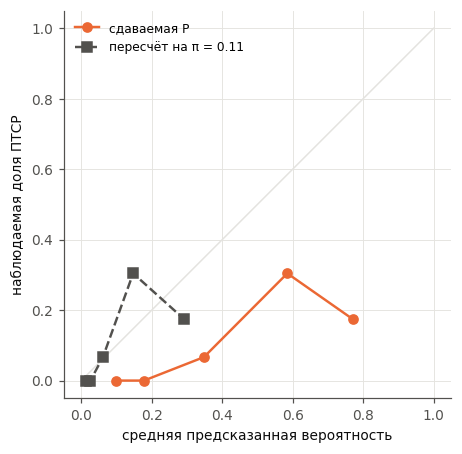

,испытуемых,средняя P,доля ПТСР,пересчёт на долю ПТСР в данных
0,46,0.098,0.000,0.013
1,46,0.178,0.000,0.026
2,45,0.348,0.067,0.061
3,46,0.585,0.304,0.147
4,46,0.771,0.174,0.292


In [11]:
rel = pd.DataFrame(report["p"]["reliability"])
prevalence = ptsd.mean()
balanced = rel["mean_p"] / (1 - rel["mean_p"]) * prevalence / (1 - prevalence)
rel["пересчёт на долю ПТСР в данных"] = balanced / (1 + balanced)
fig, ax = plt.subplots(figsize=(4.4, 4.2))
ax.plot([0, 1], [0, 1], color=viz.GRID, lw=1)
ax.plot(rel["mean_p"], rel["observed"], "o-", color=viz.COHORT_COLORS[config.GROUP_PTSD], label="сдаваемая P")
ax.plot(rel["пересчёт на долю ПТСР в данных"], rel["observed"], "s--", color=viz.TEXT_MUTED, label=f"пересчёт на π = {prevalence:.2f}")
ax.set_xlabel("средняя предсказанная вероятность")
ax.set_ylabel("наблюдаемая доля ПТСР")
ax.set_aspect("equal")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
rel.rename(columns={"n": "испытуемых", "mean_p": "средняя P", "observed": "доля ПТСР"})

## 3.9 Оценка баллов по формуле ТЗ

Объективная часть оценки: `30·max(0, (AUC − 0.5)/0.5)` на паре «ПТСР/контроль» и `20·(1 − FPR)` на нормах 65+ и соматоформных при пороге 0.5. Состав тестовой пары неизвестен, поэтому AUC-часть показана для двух вариантов; границы — по 95% ДИ. Это оценка по данным разработки, а не прогноз результата на закрытом тесте.

По формуле ТЗ чувствительность при пороге не оценивается: AUC не зависит от калибровки, а специфичность растёт при сдвиге вероятностей вниз. Калибровка по составу обучения (протокол 6) давала специфичность-часть почти 20 из 20 при той же AUC, но ни один испытуемый с ПТСР не получал P ≥ 0.5. Сдаётся сбалансированная калибровка: модель при пороге 0.5 выявляет ПТСР ценой части баллов за специфичность.

In [12]:
def auc_points(a: float) -> float:
    return 30.0 * max(0.0, (a - 0.5) / 0.5)


spec_pooled = report["p"]["specificity_ageing_and_somatoform_pooled"]
score = {}
for name, key in auc_rows.items():
    a = report["p_raw"][key]
    score[f"AUC-часть, {name}"] = [auc_points(a["value"]), auc_points(a["ci_low"]), auc_points(a["ci_high"])]
score["специфичность-часть, 65+ и соматоформные"] = [20 * spec_pooled["value"], 20 * spec_pooled["ci_low"], 20 * spec_pooled["ci_high"]]
pd.DataFrame(score, index=["оценка", "нижняя граница", "верхняя граница"]).T.round(1)

,оценка,нижняя граница,верхняя граница
"AUC-часть, ПТСР / нормы < 65",20.3,15.9,24.1
"AUC-часть, ПТСР / нормы A, B, доп. партия",13.2,6.6,19.5
"специфичность-часть, 65+ и соматоформные",12.6,10.5,14.5


## 3.10 Выводы

1. **Запуск.** Модель запускается интерфейсом ТЗ без переобучения (`load` + `run`, около 0.1 с на испытуемого) и работает с сырыми EDF. Пустая папка, неполный набор файлов, повреждённый файл и кириллические имена не прерывают запуск и дают вероятность в [0, 1]. Признаки при инференсе совпадают с обучающими (расхождение вероятностей 3·10⁻¹⁶).
2. **Оценка на обучающих данных оптимистична** (AUC 0.92 против норм моложе 65), поэтому метрики берутся только из OOF вложенной валидации.
3. **ROC-AUC (OOF):** ПТСР против норм моложе 65 лет — 0.838 [0.765; 0.901]; против норм форматов A/B и дополнительной партии — 0.720 [0.610; 0.825]; против нормы формата A отдельно — 0.62, против нормы формата C — 1.00. Различение сильнее всего там, где нормы отличаются форматом или партией, — это разбирается в ноутбуке 4.
4. **Порог 0.5:** чувствительность 0.80 [0.63; 0.96]; специфичность на нормах 65+ 0.78 [0.61; 0.91], на соматоформных 0.58 [0.47; 0.69]; сбалансированная точность 0.75 (ПТСР против норм моложе 65) и 0.73 (против всех не-ПТСР). Больше всего ложноположительных у нормы формата A (14 из 20) и дополнительной партии (17 из 40), ни одного — у нормы формата C.
5. **Возраст:** специфичность ниже всего у норм 17–29 лет (0.60) — это в основном дополнительная партия и норма A, — 0.82–0.86 у норм 30–64 лет и 0.78 у 65+. Возраст здесь переплетён с партией; отдельная проверка — ноутбук 4.
6. **Калибровка** сбалансирована по замыслу: P завышена относительно доли ПТСР в данных (11%) и пересчитывается на любую распространённость через шансы. Две верхние корзины немонотонны (доля ПТСР 0.30 и 0.17 по 46 испытуемых) — ранжирование в верхней части шкалы неидеально.
7. **Оценка баллов** по данным разработки: AUC-часть 13–20 из 30 в зависимости от состава пары «ПТСР/контроль», специфичность-часть 12.6 [10.5; 14.5] из 20.

In [13]:
shutil.rmtree(tmp, ignore_errors=True)